In [1]:
# imports

from sklearn.metrics import precision_score, recall_score, f1_score, hamming_loss
import matplotlib.pyplot as plt
import numpy as np
from tabulate import tabulate
import pandas as pd
import os
from pathlib import Path
import json

import plotly.graph_objects as go
import plotly.io as pio

import seaborn as sns


## Utilities

In [2]:


def calculate_metrics(gt, pred):
    # Calculate metrics
    # if gt is None or pred is None or len(gt) < 1 or len(pred) < 1:
    #     print(gt, pred)
    #     return (0, 0, 0)
    # [print(type(a), type(b), a, b, a in [0, 1] and b in [0, 1]) for a, b in zip (gt, pred)]
    # print("==="*10)
    precision = precision_score(gt, pred)
    recall = recall_score(gt, pred)
    f1 = f1_score(gt, pred)
    return (precision, recall, f1)

def get_sep_metrics(gt_comb, pred_comb):
    # gt_comb is array of 2-bit codes(so is pred_comb
    # This function returns 2 sets of precision, recall, and f1 (1 for each class independenty)
    gt_a = [int(i[0]) for i in gt_comb]
    gt_h = [int(i[1]) for i in gt_comb]
    
    pred_a = [int(i[0]) for i in pred_comb]
    pred_h = [int(i[1]) for i in pred_comb]

    return calculate_metrics(gt_a, pred_a), calculate_metrics(gt_h, pred_h), hamming_loss([(a, b) for a, b in zip(gt_a, gt_h)], [(a, b) for a, b in zip(pred_a, pred_h)])

def build_results_dataframe(root_path):
    data_list = []
    root = Path(root_path)

    keys_to_extract = ["image_id", "ground_truth", "model_prediction"]

    # Search for all results.json files recursively
    for json_path in root.rglob("results.json"):
        try:
            with open(json_path, 'r') as f:
                content = json.load(f)

            for result in content.get("results"):
                # Extract the specific keys
                extracted_data = {key: result.get(key) for key in keys_to_extract}
                
                # Map path parts to columns
                # Path: "Image / zero_shot / model_a / results.json"
                # parts[-4] = Task, parts[-3] = Strategy, parts[-2] = Model
                parts = json_path.parts
                row = {
                    "mode": parts[-4],
                    "prompt": parts[-3],
                    "model": parts[-2][:-7],
                    **extracted_data
                }
                data_list.append(row)
            
        except (json.JSONDecodeError, IOError) as e:
            print(f"Skipping {json_path}: {e}")

    # Create the DataFrame once from the list of dictionaries
    return pd.DataFrame(data_list)

models = ["mistralai/ministral-3b-2512", "mistralai/ministral-14b-2512", "mistralai/mistral-large-2512", "google/gemini-3-flash-preview", "google/gemini-2.5-flash", "openai/gpt-4.1"]

## Data Loading/Cleaning

In [3]:
# Usage example for the 'master' dataframe
# df = build_results_dataframe(root_directory)
# df.query("mode == 'Image' and prompt == 'cot' and model.str.contains('large')" )
df = build_results_dataframe("./results copy/Our_Dataset")
df_veri = build_results_dataframe("./results copy/VERI_Dataset")
df.dropna(inplace=True)
df_veri.dropna(inplace=True)

# cleaning data

df.drop(df.query("ground_truth not in ['11', '10', '01', '00'] or model_prediction not in ['00', '01', '10', '11']").index, inplace=True)

df_veri.drop(df.query("ground_truth not in ['11', '10', '01', '00'] or model_prediction not in ['00', '01', '10', '11']").index, inplace=True)

## Data Transformation/Aggregation

In [4]:



img_fs_gpt = df.query("model.str.contains('gpt') and mode == 'Image' and prompt == 'few_shot'")
get_sep_metrics(img_fs_gpt["ground_truth"], img_fs_gpt["model_prediction"])
tables = []
for mode in ["Image", "Dense Captions"]:
    table = []
    for prompt in ["cot", "few_shot", "zero_shot"]:
        for model in ["ministral-3b", "ministral-14b", "mistral-large", "gemini-3-flash", "gemini-2.5-flash", "gpt-4.1"]:
            # Exclude this since too many errors
            if prompt == "cot" and "2.5" in model and mode == "Dense Captions":
                continue
            data = df.query(
                f"model.str.contains('{model}') and mode == '{mode}' and prompt == '{prompt}'"
            )
            
            metrics = get_sep_metrics(
                data["ground_truth"], data["model_prediction"]
            )
            row = [model, prompt, *metrics[0], *metrics[1], metrics[2]]
            table.append(row)
    tables.append(table)

image_results = pd.DataFrame(
    tables[0],
    columns = [
        "model",
        "prompt",
        "anom_precision",
        "anom_recall",
        "anom_f1",
        "haz_precision",
        "haz_recall",
        "haz_f1",
        "hamming_loss"
    ]
)
dense_cap_results = pd.DataFrame(
    tables[1],
    columns = [
        "model",
        "prompt",
        "anom_precision",
        "anom_recall",
        "anom_f1",
        "haz_precision",
        "haz_recall",
        "haz_f1",
        "hamming_loss"
    ]
)

hamming_loss_results = pd.merge(image_results[["model", "prompt", "hamming_loss"]], dense_cap_results[["model", "prompt", "hamming_loss"]], on=["model", "prompt"], how="inner", suffixes=["_im", "_dc"])
print(hamming_loss_results.to_latex(float_format="%.2f"))
# print(pd.DataFrame(zip(*hamming_loss_res), columns=["img", "dense_cap"]))
# dense_cap_results.query("model.str.contains('ministral')")

\begin{tabular}{lllrr}
\toprule
 & model & prompt & hamming_loss_im & hamming_loss_dc \\
\midrule
0 & ministral-3b & cot & 0.36 & 0.41 \\
1 & ministral-14b & cot & 0.41 & 0.41 \\
2 & mistral-large & cot & 0.31 & 0.34 \\
3 & gemini-3-flash & cot & 0.28 & 0.28 \\
4 & gpt-4.1 & cot & 0.26 & 0.29 \\
5 & ministral-3b & few_shot & 0.32 & 0.35 \\
6 & ministral-14b & few_shot & 0.28 & 0.29 \\
7 & mistral-large & few_shot & 0.26 & 0.26 \\
8 & gemini-3-flash & few_shot & 0.23 & 0.25 \\
9 & gemini-2.5-flash & few_shot & 0.25 & 0.27 \\
10 & gpt-4.1 & few_shot & 0.24 & 0.27 \\
11 & ministral-3b & zero_shot & 0.40 & 0.33 \\
12 & ministral-14b & zero_shot & 0.33 & 0.38 \\
13 & mistral-large & zero_shot & 0.31 & 0.32 \\
14 & gemini-3-flash & zero_shot & 0.24 & 0.30 \\
15 & gemini-2.5-flash & zero_shot & 0.31 & 0.26 \\
16 & gpt-4.1 & zero_shot & 0.28 & 0.29 \\
\bottomrule
\end{tabular}



## Prec. Recall Plots

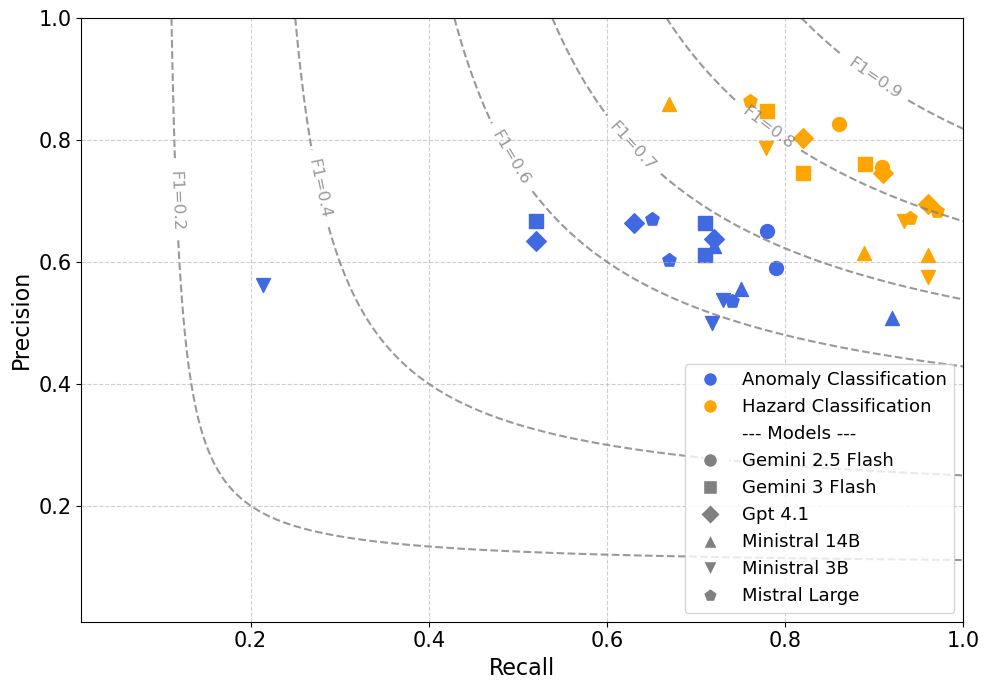

In [8]:
# Assuming your dataframe is named df
# If you need to recreate it from the image data:
# data = {
#     'model': ['ministral-3b', 'ministral-14b', 'mistral-large', 'gemini-3-flash', 'gemini-2.5-flash'],
#     'anom_p': [0.566, 0.510, 0.612, 0.589, 0.605],
#     'anom_r': [0.85, 0.97, 0.79, 0.82, 0.89],
#     'haz_p': [0.612, 0.603, 0.664, 0.732, 0.680],
#     'haz_r': [0.98, 0.99, 0.97, 0.96, 0.98]
# }
# df = pd.DataFrame(data)
df = dense_cap_results.sort_values(by="model")
# Define unique markers for each model
markers = ['o', 's', 'D', '^', 'v', 'p', '*']
model_names = df['model'].unique()
model_to_marker = dict(zip(model_names, markers))

plt.figure(figsize=(10, 7))

for _, row in df.iterrows():
    m = model_to_marker[row['model']]
    
    # Plot Anomaly point
    plt.scatter(row['anom_recall'], row['anom_precision'], 
                color='royalblue', marker=m, s=100, label=f"{row['model']} (Anom)" if _ == 0 else "")
    
    # Plot Hazard point
    plt.scatter(row['haz_recall'], row['haz_precision'], 
                color='orange', marker=m, s=100, label=f"{row['model']} (Haz)" if _ == 0 else "")

# 3. Generate F1 Iso-curves (the background contours)
x = np.linspace(0.01, 1, 100)
y = np.linspace(0.01, 1, 100)
X, Y = np.meshgrid(x, y)
F1 = 2 * (X * Y) / (X + Y)

levels = [0.2, 0.4, 0.6, 0.7, 0.8, 0.9]
contours = plt.contour(X, Y, F1, levels=levels, colors='gray', alpha=0.8, linestyles='--')
plt.clabel(contours, inline=True, fontsize=12, fmt='F1=%.1f')

# Create custom legend for Colors and Shapes
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Anomaly Classification', markerfacecolor='royalblue', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Hazard Classification', markerfacecolor='orange', markersize=10),
    Line2D([0], [0], color='w', label='--- Models ---')
] + [Line2D([0], [0], marker=model_to_marker[name], color='w', label=name.replace("-", " ").title(), 
            markerfacecolor='gray', markersize=10) for name in model_names]

plt.legend(handles=legend_elements, loc='lower right', fontsize=13)
# plt.title('Precision and Recall in Classifying Anomalies and Hazards with Dense Captions')
plt.xlabel('Recall', fontsize = 16)
plt.ylabel('Precision', fontsize = 16)
plt.gca().tick_params(axis='both', which="both", labelsize=15)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.savefig("dense_cap_mode_prec_vs_recall.png", dpi=300)
plt.show()

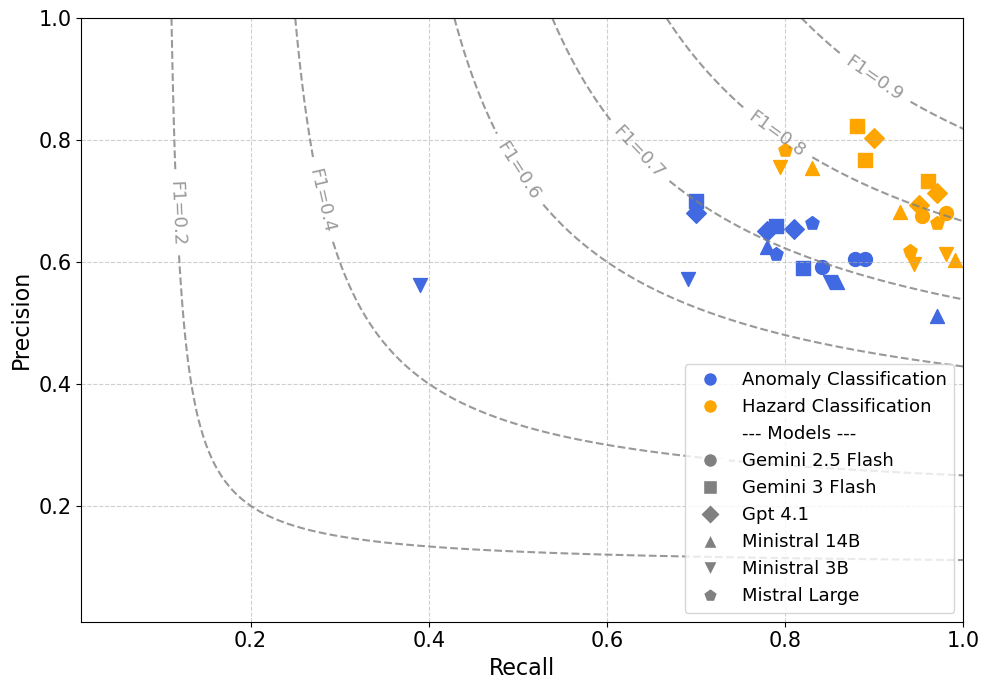

In [9]:
df = image_results.sort_values(by="model")
# Define unique markers for each model
markers = ['o', 's', 'D', '^', 'v', 'p', '*']
model_names = df['model'].unique()
model_to_marker = dict(zip(model_names, markers))

plt.figure(figsize=(10, 7))

for _, row in df.iterrows():
    m = model_to_marker[row['model']]
    
    # Plot Anomaly point
    plt.scatter(row['anom_recall'], row['anom_precision'], 
                color='royalblue', marker=m, s=100, label=f"{row['model']} (Anom)" if _ == 0 else "")
    
    # Plot Hazard point
    plt.scatter(row['haz_recall'], row['haz_precision'], 
                color='orange', marker=m, s=100, label=f"{row['model']} (Haz)" if _ == 0 else "")

# 3. Generate F1 Iso-curves (the background contours)
x = np.linspace(0.01, 1, 100)
y = np.linspace(0.01, 1, 100)
X, Y = np.meshgrid(x, y)
F1 = 2 * (X * Y) / (X + Y)

levels = [0.2, 0.4, 0.6, 0.7, 0.8, 0.9]
contours = plt.contour(X, Y, F1, levels=levels, colors='gray', alpha=0.8, linestyles='--')
plt.clabel(contours, inline=True, fontsize=13, fmt='F1=%.1f')

# Create custom legend for Colors and Shapes
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Anomaly Classification', markerfacecolor='royalblue', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Hazard Classification', markerfacecolor='orange', markersize=10),
    Line2D([0], [0], color='w', label='--- Models ---')
] + [Line2D([0], [0], marker=model_to_marker[name], color='w', label=name.replace("-", " ").title(), 
            markerfacecolor='gray', markersize=10) for name in model_names]

plt.legend(handles=legend_elements, loc='lower right', fontsize = 13)
# plt.title('Precision and Recall in Classifying Anomalies and Hazards with Images')
plt.xlabel('Recall', fontsize=16)
plt.ylabel('Precision', fontsize=16)
plt.gca().tick_params(axis='both', which="both", labelsize=15)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.savefig("img_mode_prec_vs_recall.png", dpi=300)
plt.show()

## Radar Plots

In [7]:
def format_label(text, n):
    words = text.split()
    # Create chunks of size n
    lines = [' '.join(words[i:i + n]) for i in range(0, len(words), n)]
    return '<br>'.join(lines)
def close_loop(data_list):
    return data_list + [data_list[0]]
# Get radius counts

prompt_types = df_veri["prompt"].unique()

safe_counts = {pt: {key: 0 for key in df_veri["model"].unique()} for pt in prompt_types}
danger_counts = {pt: {key: 0 for key in df_veri["model"].unique()} for pt in prompt_types}

for i in range(len(df_veri)):
    row = df_veri.iloc[i]
    if row["model_prediction"] in ["00", "01"] :
        safe_counts[row["prompt"]][row["model"]] += 1 
    else:
        danger_counts[row["prompt"]][row["model"]] += 1 


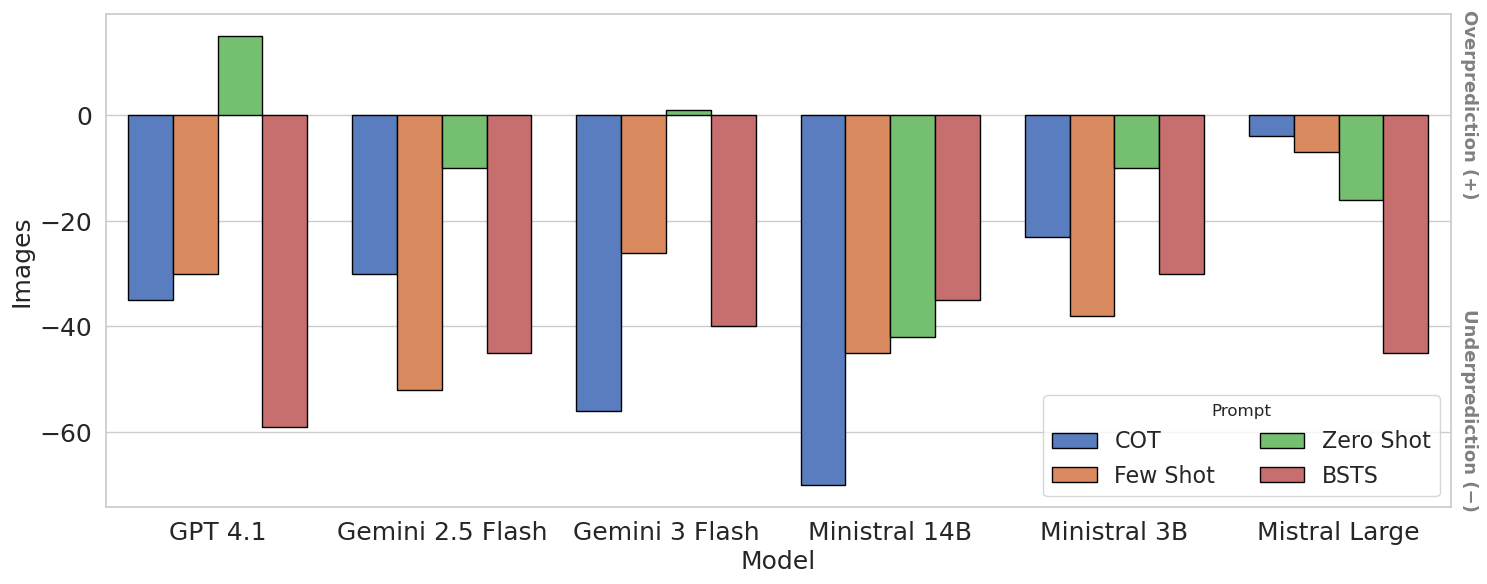

In [30]:

# 2. Set the 'Publishing' Theme
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 6))
veri_safe_counts_df = pd.DataFrame(safe_counts)
veri_safe_counts_df.reset_index(inplace=True, names="model")
veri_safe_counts_df = veri_safe_counts_df.melt(id_vars="model", var_name="prompt", value_name="num")

veri_safe_counts_df["num"] = veri_safe_counts_df["num"] - 100

veri_safe_counts_df.replace(regex=r"^.*mistral-large.*$", value="Mistral Large", inplace=True)
veri_safe_counts_df.replace(regex=r"^.*gpt-4.1.*$", value="GPT 4.1", inplace=True)
veri_safe_counts_df.replace(regex=r"^.*ministral-3.*$", value="Ministral 3B", inplace=True)
veri_safe_counts_df.replace(regex=r"^.*gemini-3.*$", value="Gemini 3 Flash", inplace=True)
veri_safe_counts_df.replace(regex=r"^.*gemini-2.5.*$", value="Gemini 2.5 Flash", inplace=True)
veri_safe_counts_df.replace(regex=r"^.*ministral-14b.*$", value="Ministral 14B", inplace=True)

veri_safe_counts_df.replace(regex=r"^cot$", value="COT", inplace=True)
veri_safe_counts_df.replace(regex=r"^zero.*$", value="Zero Shot", inplace=True)
veri_safe_counts_df.replace(regex=r"^bsts$", value="BSTS", inplace=True)
veri_safe_counts_df.replace(regex=r"^few.*$", value="Few Shot", inplace=True)

veri_safe_counts_df.sort_values(by="model", inplace=True)

# 3. Create the Grouped Bar Chart
ax = sns.barplot(
    data=veri_safe_counts_df, 
    x="model",           # 6 Groups
    y="num",    # The Value
    hue="prompt",         # 5 Bars per group (using 'sex' as example)
    palette="muted",   # Professional, muted colors
    edgecolor="black"  # Clean separation between bars
)

# # --- 3. Add the Horizontal Target Line ---
# # axhline draws a line from x=0 (min) to x=1 (max) of the visible plot area
# ax.axhline(
#     y=100, 
#     color='gold',    # Contrasting, high-vis color
#     linestyle='--',  # Professional dashed look
#     linewidth=2.5,   # Thick enough to be clear
#     label='Target'   # Adds it to the main legend, if needed
# )

# # --- 4. Add the Labeled Text ---
# # ax.text(x_coord, y_coord, text_string)
# # Using paper coordinates (transform) to place the text relative to the view, 
# # not the specific data points.
# ax.text(
#     x=5.2, 
#     y=100 + 0.1, 
#     s=f"Target: {100}",
#     color="gold",
#     fontweight="bold",
#     fontsize=12,
#     ha="center",           # Center the text horizontally on the x-coordinate
#     va="bottom",           # Align the bottom of the text to the y-coordinate
#     clip_on=True
# )

# Add labels for Under/Over prediction near the axis
ax.text(1.02, 20, 'Overprediction (+)', transform=ax.get_yaxis_transform(), rotation=-90,
        va='top', ha='right', fontsize=13, fontweight='bold', color='gray')

ax.text(1.02, -75, 'Underprediction (−)', transform=ax.get_yaxis_transform(), rotation = -90,
        va='bottom', ha='right', fontsize=13, fontweight='bold', color='gray')

# 4. Refine for Publication
# plt.title("Error in Number of Images Classified Safe on VERI Dataset", fontsize=18, fontweight='bold')
plt.xlabel("Model", fontsize=18)
plt.ylabel("Images", fontsize=18)
plt.legend(title="Prompt", loc='lower right', ncol=2, fontsize = 16)
plt.gca().tick_params(axis='both', which="both", labelsize=18)


# 5. Export high-res PNG
plt.tight_layout()
plt.savefig("baseline-compare-safe-bar.png", dpi=300, bbox_inches='tight')

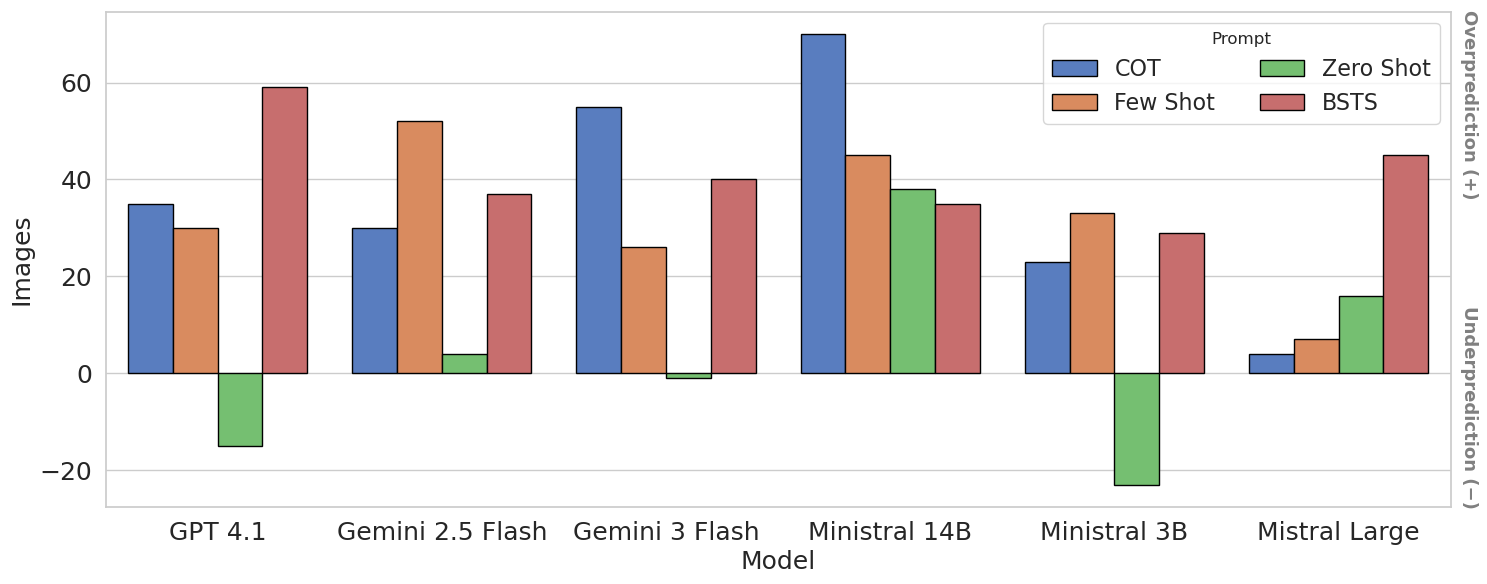

In [31]:
# 2. Set the 'Publishing' Theme
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 6))
veri_danger_counts_df = pd.DataFrame(danger_counts)
veri_danger_counts_df.reset_index(inplace=True, names="model")
veri_danger_counts_df = veri_danger_counts_df.melt(id_vars="model", var_name="prompt", value_name="num")

veri_danger_counts_df["num"] = veri_danger_counts_df["num"] - 100

veri_danger_counts_df.replace(regex=r"^.*mistral-large.*$", value="Mistral Large", inplace=True)
veri_danger_counts_df.replace(regex=r"^.*gpt-4.1.*$", value="GPT 4.1", inplace=True)
veri_danger_counts_df.replace(regex=r"^.*ministral-3.*$", value="Ministral 3B", inplace=True)
veri_danger_counts_df.replace(regex=r"^.*gemini-3.*$", value="Gemini 3 Flash", inplace=True)
veri_danger_counts_df.replace(regex=r"^.*gemini-2.5.*$", value="Gemini 2.5 Flash", inplace=True)
veri_danger_counts_df.replace(regex=r"^.*ministral-14b.*$", value="Ministral 14B", inplace=True)

veri_danger_counts_df.sort_values(by="model", inplace=True)

veri_danger_counts_df.replace(regex=r"^cot$", value="COT", inplace=True)
veri_danger_counts_df.replace(regex=r"^zero.*$", value="Zero Shot", inplace=True)
veri_danger_counts_df.replace(regex=r"^bsts$", value="BSTS", inplace=True)
veri_danger_counts_df.replace(regex=r"^few.*$", value="Few Shot", inplace=True)

# 3. Create the Grouped Bar Chart
ax = sns.barplot(
    data=veri_danger_counts_df, 
    x="model",           # 6 Groups
    y="num",    # The Value
    hue="prompt",         # 5 Bars per group (using 'sex' as example)
    palette="muted",   # Professional, muted colors
    edgecolor="black"  # Clean separation between bars
)

# # --- 3. Add the Horizontal Target Line ---
# # axhline draws a line from x=0 (min) to x=1 (max) of the visible plot area
# ax.axhline(
#     y=100, 
#     color='gold',    # Contrasting, high-vis color
#     linestyle='--',  # Professional dashed look
#     linewidth=2.5,   # Thick enough to be clear
#     label='Target'   # Adds it to the main legend, if needed
# )

# # --- 4. Add the Labeled Text ---
# # ax.text(x_coord, y_coord, text_string)
# # Using paper coordinates (transform) to place the text relative to the view, 
# # not the specific data points.
# ax.text(
#     x=5.2, 
#     y=100 + 0.1, 
#     s=f"Target: {100}",
#     color="gold",
#     fontweight="bold",
#     fontsize=12,
#     ha="center",           # Center the text horizontally on the x-coordinate
#     va="bottom",           # Align the bottom of the text to the y-coordinate
#     clip_on=True
# )

ax.text(1.02, 75, 'Overprediction (+)', transform=ax.get_yaxis_transform(), rotation=-90,
        va='top', ha='right', fontsize=13, fontweight='bold', color='gray')

ax.text(1.02, -28, 'Underprediction (−)', transform=ax.get_yaxis_transform(), rotation = -90,
        va='bottom', ha='right', fontsize=13, fontweight='bold', color='gray')

# 4. Refine for Publication
# plt.title("Error in Number of Images Classified Dangerous on VERI Dataset", fontsize=18, fontweight='bold')
plt.xlabel("Model", fontsize=18)
plt.ylabel("Images", fontsize=18)
plt.legend(title="Prompt", loc='upper right', ncol=2, fontsize = 16)
plt.gca().tick_params(axis='both', which="both", labelsize=18)

# 5. Export high-res PNG
plt.tight_layout()
plt.savefig("baseline-compare-danger-bar.png", dpi=300, bbox_inches='tight')

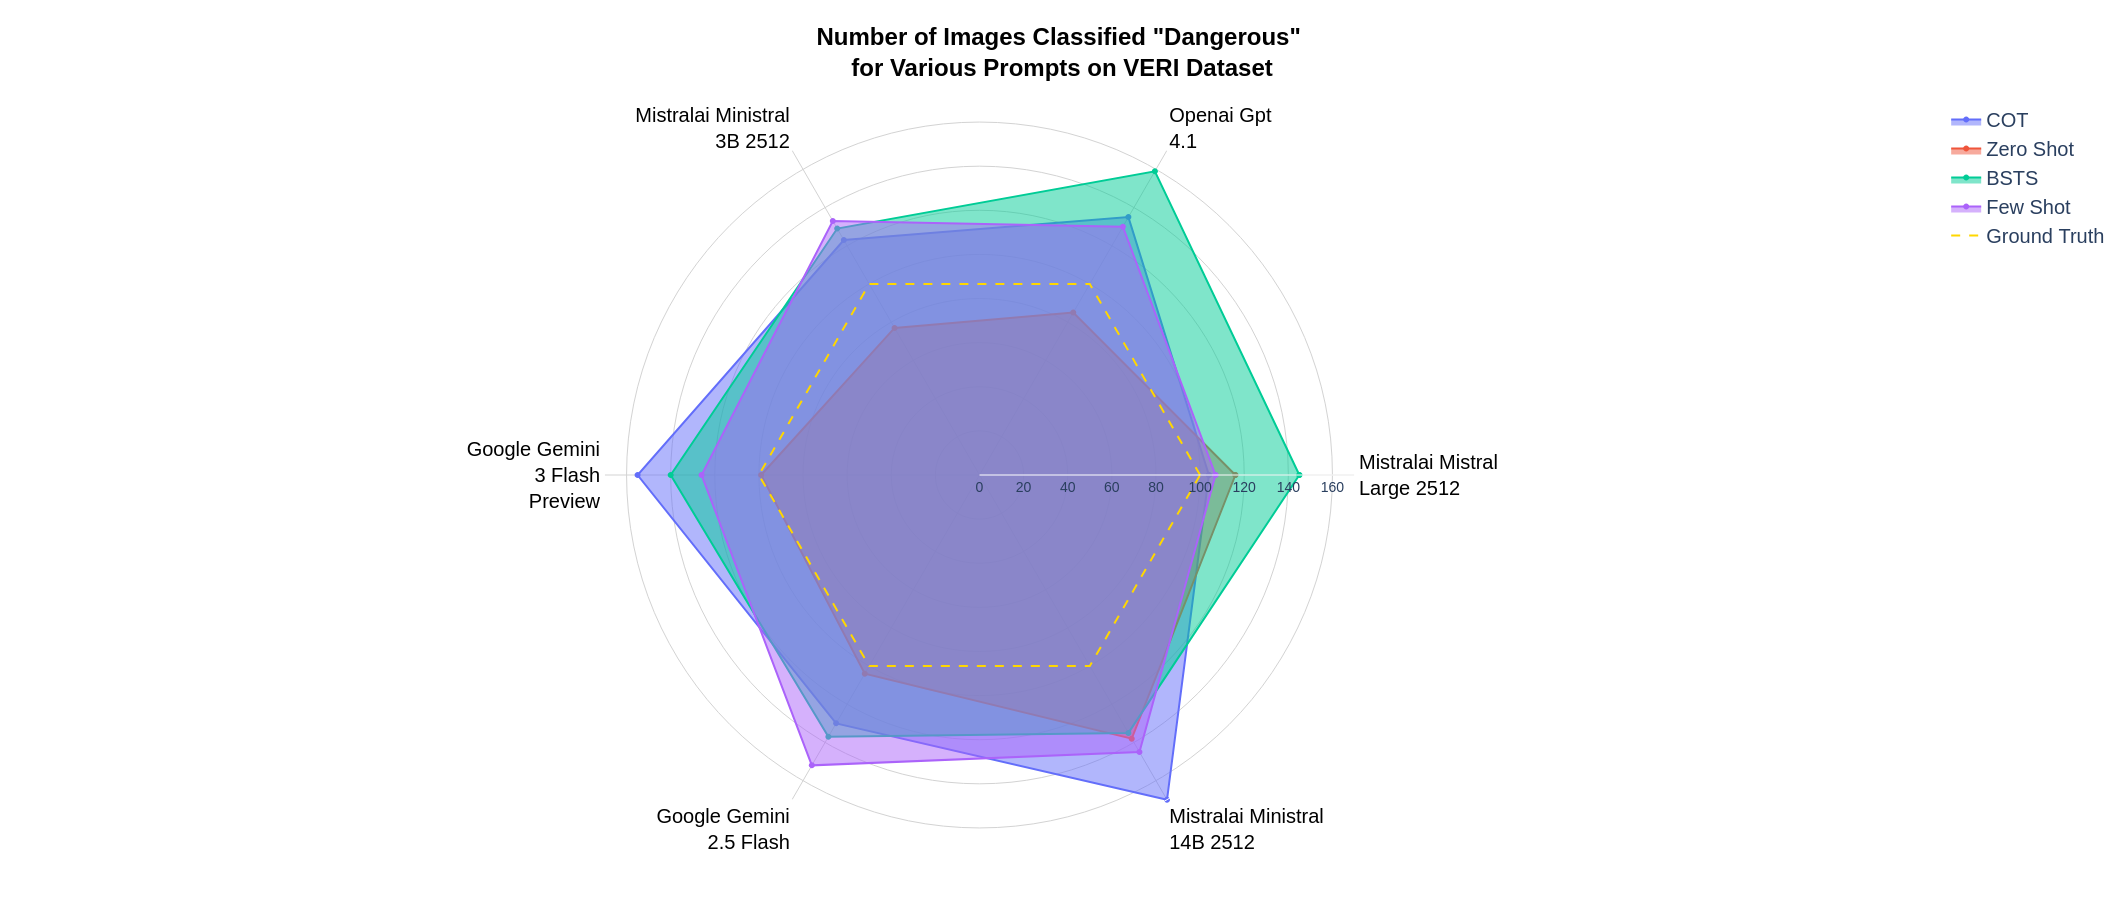

In [16]:
## Dangerous Plot

# pio.renderers.default = "notebook_connected" # Or "colab" if using Google Colab
fig = go.Figure()


# Make the Plot
for prompt, label in zip(prompt_types, ["COT", "Zero Shot", "BSTS", "Few Shot"]):
    fig.add_trace(go.Scatterpolar(
      r=close_loop(list(danger_counts[prompt].values())),
      theta=close_loop([format_label(" ".join(i.split("-")[:4]).title().replace("_", " "), 2) for i in danger_counts[prompt].keys()]),
      fill='toself',
      name=label
    ))

# Target
fig.add_trace(go.Scatterpolar(
    r=[100] * len(fig.data[0].theta), # Creates a list of 4s the same length as theta
    theta=fig.data[0].theta,        # Copies the categories exactly
    mode='lines',
    line=dict(color='gold', dash='dash'),
    name='Ground Truth'
))

fig.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, max([j for i in danger_counts.values() for j in i.values()])],
            gridcolor="lightgrey",
            tickfont=dict(size=14)
        ),
        angularaxis=dict(
            gridcolor="lightgrey",
            tickfont=dict(size=20, color="black")
        ),
        bgcolor="white" # Clean background
    ),
    width=1200,
    height=900,
    title={
        'text': "<b>Number of Images Classified \"Dangerous\" <br>for Various Prompts on VERI Dataset</br>", # Bold HTML tag
        'y': 0.95,           # Vertical position (0 to 1)
        'x': 0.5,            # Horizontal position (0.5 is centered)
        'xanchor': 'center', # Anchor point
        'yanchor': 'top',
        'font': dict(
            family="Arial, sans-serif",
            size=24,
            color="black"
        )
    },
    margin=dict(l=50, r=50, b=50, t=100), # Tighten whitespace
    showlegend=True,
    paper_bgcolor="white",
    font=dict(family="Arial", size=20) # Standard publication font
)


# fig.show()

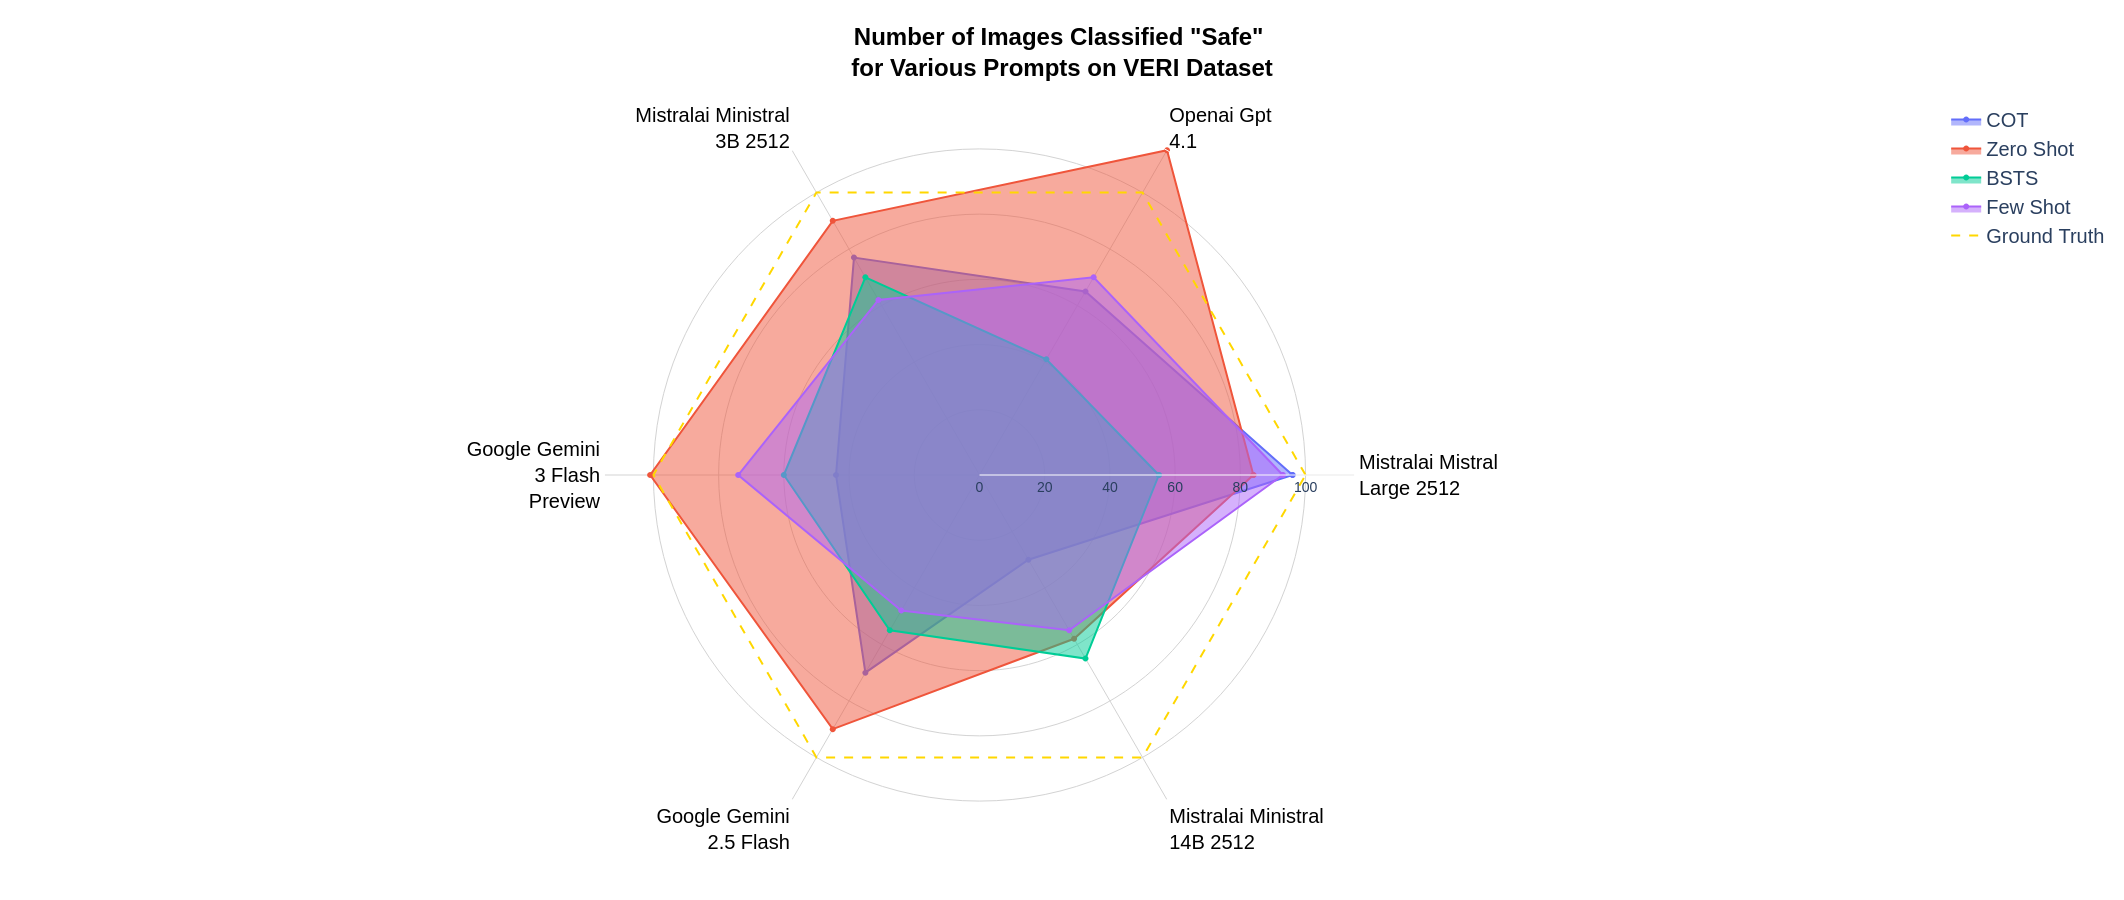

In [17]:
## Dangerous Plot

# pio.renderers.default = "notebook_connected" # Or "colab" if using Google Colab
fig = go.Figure()

# Make the Plot
for prompt, label in zip(prompt_types, ["COT", "Zero Shot", "BSTS", "Few Shot"]):
    fig.add_trace(go.Scatterpolar(
      r=close_loop(list(safe_counts[prompt].values())),
      theta=close_loop([format_label(" ".join(i.split("-")[:4]).title().replace("_", " "), 2) for i in safe_counts[prompt].keys()]),
      fill='toself',
      name=label
    ))

# Target
fig.add_trace(go.Scatterpolar(
    r=[100] * len(fig.data[0].theta), # Creates a list of 4s the same length as theta
    theta=fig.data[0].theta,        # Copies the categories exactly
    mode='lines',
    line=dict(color='gold', dash='dash'),
    name='Ground Truth'
))

fig.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, max([j for i in safe_counts.values() for j in i.values()])],
            gridcolor="lightgrey",
            tickfont=dict(size=14)
        ),
        angularaxis=dict(
            gridcolor="lightgrey",
            tickfont=dict(size=20, color="black")
        ),
        bgcolor="white" # Clean background
    ),
    width=1200,
    height=900,
    title={
        'text': "<b>Number of Images Classified \"Safe\" <br>for Various Prompts on VERI Dataset</br>", # Bold HTML tag
        'y': 0.95,           # Vertical position (0 to 1)
        'x': 0.5,            # Horizontal position (0.5 is centered)
        'xanchor': 'center', # Anchor point
        'yanchor': 'top',
        'font': dict(
            family="Arial, sans-serif",
            size=24,
            color="black"
        )
    },
    margin=dict(l=50, r=50, b=50, t=100), # Tighten whitespace
    showlegend=True,
    paper_bgcolor="white",
    font=dict(family="Arial", size=20) # Standard publication font
)


# fig.show()

# Some test code for bar graphs(adapt as necessary)

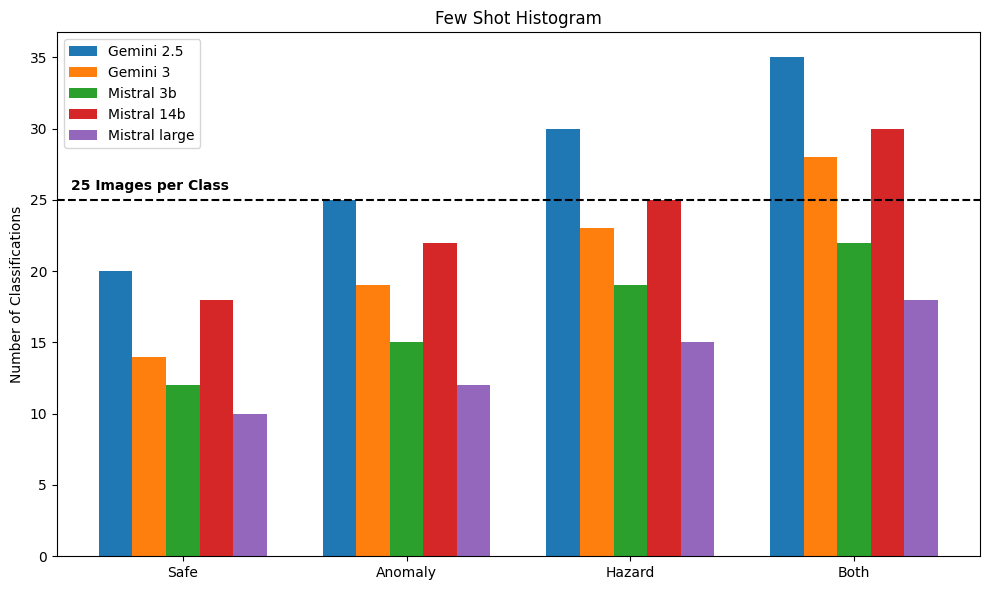

In [10]:

# 1. Prepare the data
groups = ['Safe', 'Anomaly', 'Hazard', 'Both']
categories = ['Gemini 2.5', 'Gemini 3', 'Mistral 3b', 'Mistral 14b', 'Mistral large']

# Example data: 5 bars per group (4 groups total)
data = {
    'Gemini 2.5': [20, 25, 30, 35],
    'Gemini 3': [14, 19, 23, 28],
    'Mistral 3b': [12, 15, 19, 22],
    'Mistral 14b': [18, 22, 25, 30],
    'Mistral large': [10, 12, 15, 18]
}

# 2. Setup the positions
x = np.arange(len(groups))  # The label locations
width = 0.15  # The width of the individual bars

fig, ax = plt.subplots(figsize=(10, 6))

# 3. Plot each category with an offset
# We center the group by shifting each bar by a multiple of 'width'
for i, (name, values) in enumerate(data.items()):
    offset = i * width
    ax.bar(x + offset, values, width, label=name)

# 4. Add styling and labels
ax.set_ylabel('Number of Classifications')
ax.set_title('Few Shot Histogram')
# Center the x-ticks by adding (total_width / 2) - (half_bar_width)
ax.set_xticks(x + (width * 2)) 
ax.set_xticklabels(groups)
ax.legend()

ax.axhline(y=25, color='k', linestyle='--', linewidth=1.5, label='Target Threshold')
ax.text(x=-0.2, y=25 + 0.5, s=f'25 Images per Class', 
        color='k', fontweight='bold', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

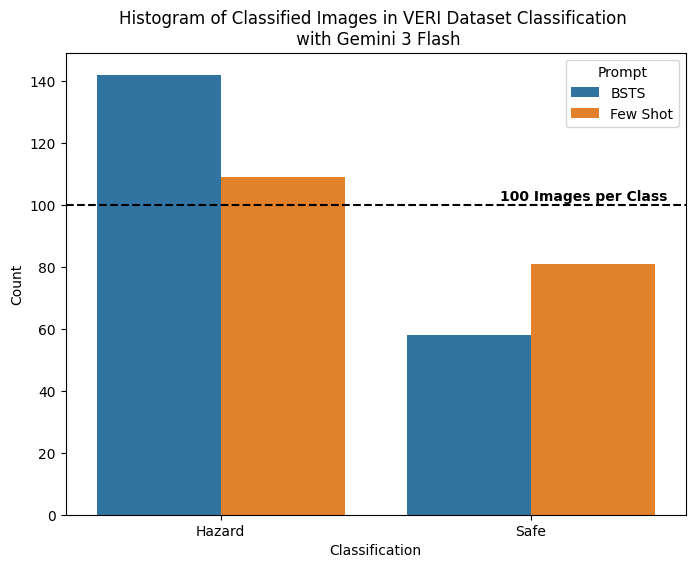

In [5]:
## Baseline Comparison
# Tallies computed from confusion matrices
data = {
    'Prompt': ['BSTS', 'Few Shot'],
    'Hazard': [99 + 43, 85 + 24],
    'Safe': [57 + 1, 76 + 5]
}
df = pd.DataFrame(data)

# 2. Reshape the dataframe for plotting (Long Format)
# We only keep 'prompt' and the metrics we want to plot (TP and TN)
df_melted = df.melt(id_vars='Prompt', value_vars=['Hazard', 'Safe'], 
                    var_name='Metric', value_name='Count')

# 3. Create the Seaborn bar plot
plt.figure(figsize=(8, 6))
sns.barplot(data=df_melted, x='Metric', y='Count', hue='Prompt')

# Optional: Add labels and title
plt.title('Histogram of Classified Images in VERI Dataset Classification \n with Gemini 3 Flash')
plt.xlabel('Classification')
plt.ylabel('Count')

plt.gca().axhline(y=100, color="k", linestyle="--")
plt.gca().text(x=0.9, y=100 + 0.5, s=f'100 Images per Class', 
        color='k', fontweight='bold', va='bottom', fontsize=10)

# Show the plot
plt.show()

print()